In [1]:
quiet_library <- function(...){suppressPackageStartupMessages(library(...))}
quiet_library(dplyr)
quiet_library(purrr)
quiet_library(tidyr)
quiet_library(data.table)
quiet_library(Seurat)
quiet_library(ggplot2)
quiet_library(glue)
quiet_library(gridExtra)
quiet_library(grid)

options(repr.matrix.max.cols=150, repr.matrix.max.rows=200, mc.cores = 20, future.globals.maxSize = 2000 * 1024^2)
fig.size <- function (height, width) {
    options(repr.plot.height = height, repr.plot.width = width)
}

In [2]:
wd <- "/home/workspace/IFN"
fig_dir <- file.path(wd, "Figures")

In [3]:
set.seed(123)

In [4]:
stims <- c("IFNa", "IFNb", "IFN-L1", "IFNg")
celltypes <- c("Bcell", "Tcell", "NK", "Monocyte")
subtypes <- c("CD4 Naive", "CD4 Memory", "Treg", "CD8 Naive", "CD8 Memory", "MAIT", "gdT", 
              "B Naive", "B Memory", "Plasma", 
              "NK.CD56hi", "NK.CD56dim", 
              "CD14 Monocyte")
celltype_cols <- c("#00b4d8", "#1b4332", "#ffbf69", "#78290f" )
subtype_cols <- c("#03045e", "#023e8a", "#0077b6", "#0096c7", "#00b4d8", "#48cae4", "#90e0ef",
                   "#1b4332", "#52b788", "#b7e4c7",
                    "#ff9f1c", "#ffbf69", 
                   "#78290f"
                  )
stim_cols <- c("#e9c46a", "#f4a261", "#e76f51", "#264653", "#2a9d8f")

In [5]:
l1_degs <- fread(file.path(wd, "DEGs", "L1_All_Celltypes_Stims_N1_DEGs.csv")) %>%
                filter(Significant == "Yes")
l2_degs <- fread(file.path(wd, "DEGs", "L2_All_Celltypes_Stims_N1_DEGs.csv")) %>%
                filter(Significant == "Yes")

### 1A. Cell Labelling Genes Stim Heatmap

In [6]:
so <- readRDS(file.path(wd, "seurat_objects", "so_complete2.rds"))

In [7]:
# stims plus unstim
conditions <- c("none", "IFNa", "IFNb", "IFNg", "IFN-L1")

In [8]:
# define heatmap annotation metadata
meta_final <- data.frame(Stim = rep(conditions, 13))
meta_final$Stim <- factor(meta_final$Stim, levels = conditions)
HA <- ComplexHeatmap::HeatmapAnnotation(df = meta_final, 
                                        col = list(Stim = c("none" = '#e9c46a', 
                                                               "IFNa" = '#f4a261',
                                                               "IFNb" = '#e76f51',
                                                               "IFNg" = '#264653',
                                                                "IFN-L1" = '#2a9d8f'
                                                               
                  )))

In [9]:
# labelling genes
final_genes <- c("CD8A", "CCR7", "FOXP3", "TRGC1", 
                  "IGHD", "CD24", "MZB1",
                  "GZMB", "LYZ")

In [10]:
# get average expression of select genes
avgexp <- AverageExpression(so %>% subset(Description %in% conditions),
                                       features = final_genes, group.by = c("Subtype", "Description"),
                         return.seurat = T)

As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.
Centering and scaling data matrix



In [11]:
avg_mat <- avgexp@assays$RNA@layers$data
colnames(avg_mat) <- rownames(avgexp@assays$RNA@cells)
rownames(avg_mat) <- rownames(avgexp@assays$RNA@features)

In [12]:
# scale expression from 0 to 1 for each gene
avg_scaled <- t(apply(avg_mat, 1, function(x) {
  min_val <- min(x)
  max_val <- max(x)
  scaled_row <- (x - min_val) / (max_val - min_val) 
  return(scaled_row)
}))


In [19]:
fig.size(3.5,17)
pdf(file.path(fig_dir, "Supp", "Sup1", "Cell_Labelling_Marker_Heatmap.pdf"), height = 3.5, width = 17)
col_fun <- circlize::colorRamp2(c(0, 1), c("white", "red3"))

ComplexHeatmap::Heatmap(
  avg_scaled, 
  name = "Expression", 
  top_annotation = HA, 
  show_row_names = TRUE, 
  show_column_names = FALSE, 
  col = col_fun, 
  column_split = factor(rep(subtypes, each = 5), levels = subtypes),
  cluster_columns = FALSE, 
  cluster_rows = FALSE,
  cluster_column_slices = FALSE,
  column_title_rot = 90,
  cell_fun = function(j, i, x, y, width, height, fill) {
    grid::grid.rect(x = x, y = y, 
                    width = width, height = height, 
                    gp = grid::gpar(col = "gray95", fill = NA, lwd = 0.5))
  }
)
dev.off()

pdf 
  2

### 1B. Cell Labelling IFNa, IFNg, Unstim PCA

In [ ]:
subtypes <- c("CD4 Naive", "CD4 Memory", "Treg", "CD8 Naive", "CD8 Memory", "MAIT", "gdT", 
              "Naive", "Memory", "Plasma", 
              "NK CD56hi", "NK CD56dim", 
              "Monocyte")

In [46]:
label_genes <- fread(file.path(wd, "cell_labelling_genes.csv"))
genes <- label_genes$Gene %>% strsplit(",") %>% unlist() %>% gsub("\\s+", "", .) %>% unique()
genes <- c(genes, "CD8A")

In [48]:
# get average expression of select genes
avgexp <- AverageExpression(so, features = genes, group.by = c("Subtype", "Description"),
                         return.seurat = T)

Warning message:
“The following 4 features were not found in the RNA assay: CD8, IGHG2, IGHG4, FCN1”
Centering and scaling data matrix



In [49]:
# format average expression matrix 
cols_keep <- colnames(avgexp@assays$RNA$data) %>% grep("IFNa|IFNg|none", ., value = T)
data_mat <- avgexp@assays$RNA$data[,cols_keep] %>% t()

In [54]:
# run pca on average expression matrix
zero_columns <- colSums(data_mat == 0) == nrow(data_mat)
data_mat <- data_mat[, !zero_columns]

pca_result <- prcomp(data_mat, scale. = TRUE) 

pc_scores <- as.data.frame(pca_result$x[, 1:2])

pc_scores$Sample <- rownames(pc_scores)
pc_scores$Stim <- pc_scores$Sample %>% stringr::str_extract("[^_]+$")
pc_scores$Subtype <- pc_scores$Sample %>% stringr::str_extract("[^_]*")


pc_scores$Subtype <- factor(pc_scores$Subtype, levels = subtypes)

null device 
          1

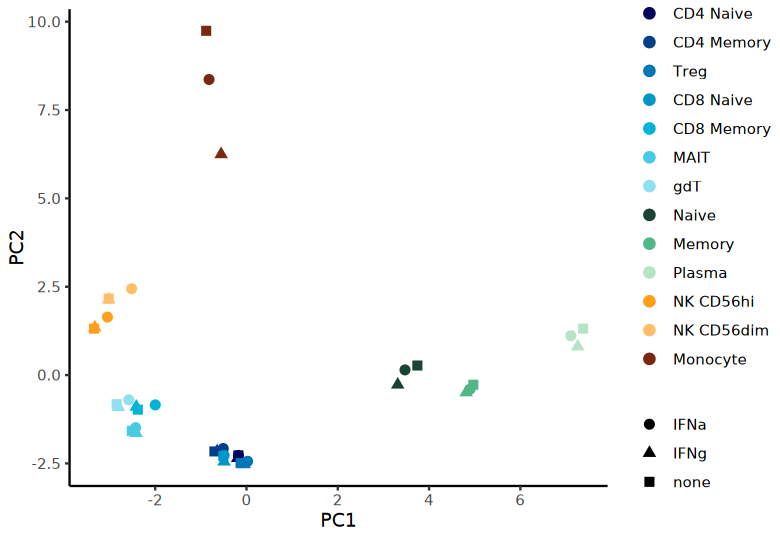

In [55]:
fig.size(4.5,6.5)
#pdf(file.path(fig_dir, "Sup1", "IFN_Receptor_nDEGs_Scatterplots.pdf"), height = 4, width = 5.5)
ggplot(pc_scores, aes(x = PC1, y = PC2, color = Subtype, shape = Stim)) +
    geom_point(size = 2.5) +
    labs(x = "PC1", y = "PC2") +
    theme_classic() + 
    scale_color_manual(values=subtype_cols) + 
    theme(legend.title = element_blank())
dev.off()

### 1C. N=1 DEG L1 Elbow Plots

In [7]:
stims <- c("IFNa", "IFNb", "IFNg", "IFN-L1")
donors <- c("3955BW", "3283BW", "2616BW", "6811BW", "3491BW")

In [8]:
# iterate over cell types and stims
ggs <- lapply(celltypes, function(c){
            lapply(stims, function(i){
                degs_all <- map_dfr(donors, function(d){ 
                
                    # read in consensus DEG for each donor
                    degs <- fread(file.path(wd, "DEGs", "MAST_N1_downsample", "Bulk", c, glue("{d}_{i}_{c}_DEGs_MAST_CDR_downsample1000_consensus.csv"))) 
                    degs$donor <- d
                    if (nrow(degs) > 0){
                        degs
                        }
                })

            # get cumulative count of shared DEGs     
            degs_all$Freq <- 1
            degs_all <- degs_all %>%
              group_by(gene) %>%
              mutate(CumulativeTally = cumsum(Freq))

            tallyDF <- as.data.frame(table(degs_all$CumulativeTally))
            tallyDF$Var1 <- as.integer(tallyDF$Var) 

            gg <- ggplot(tallyDF, aes(x=Var1, y=Freq)) + 
              geom_point()+
              geom_line() + 
                theme_classic() + 
                ylim(0,4000) + 
                labs(x = "# of samples shared DEG", y = "# of DEGs") + 
                ggtitle(glue("{c}_{i}"))
            gg
    }) 
}) %>% unlist(recursive = F)

null device 
          1

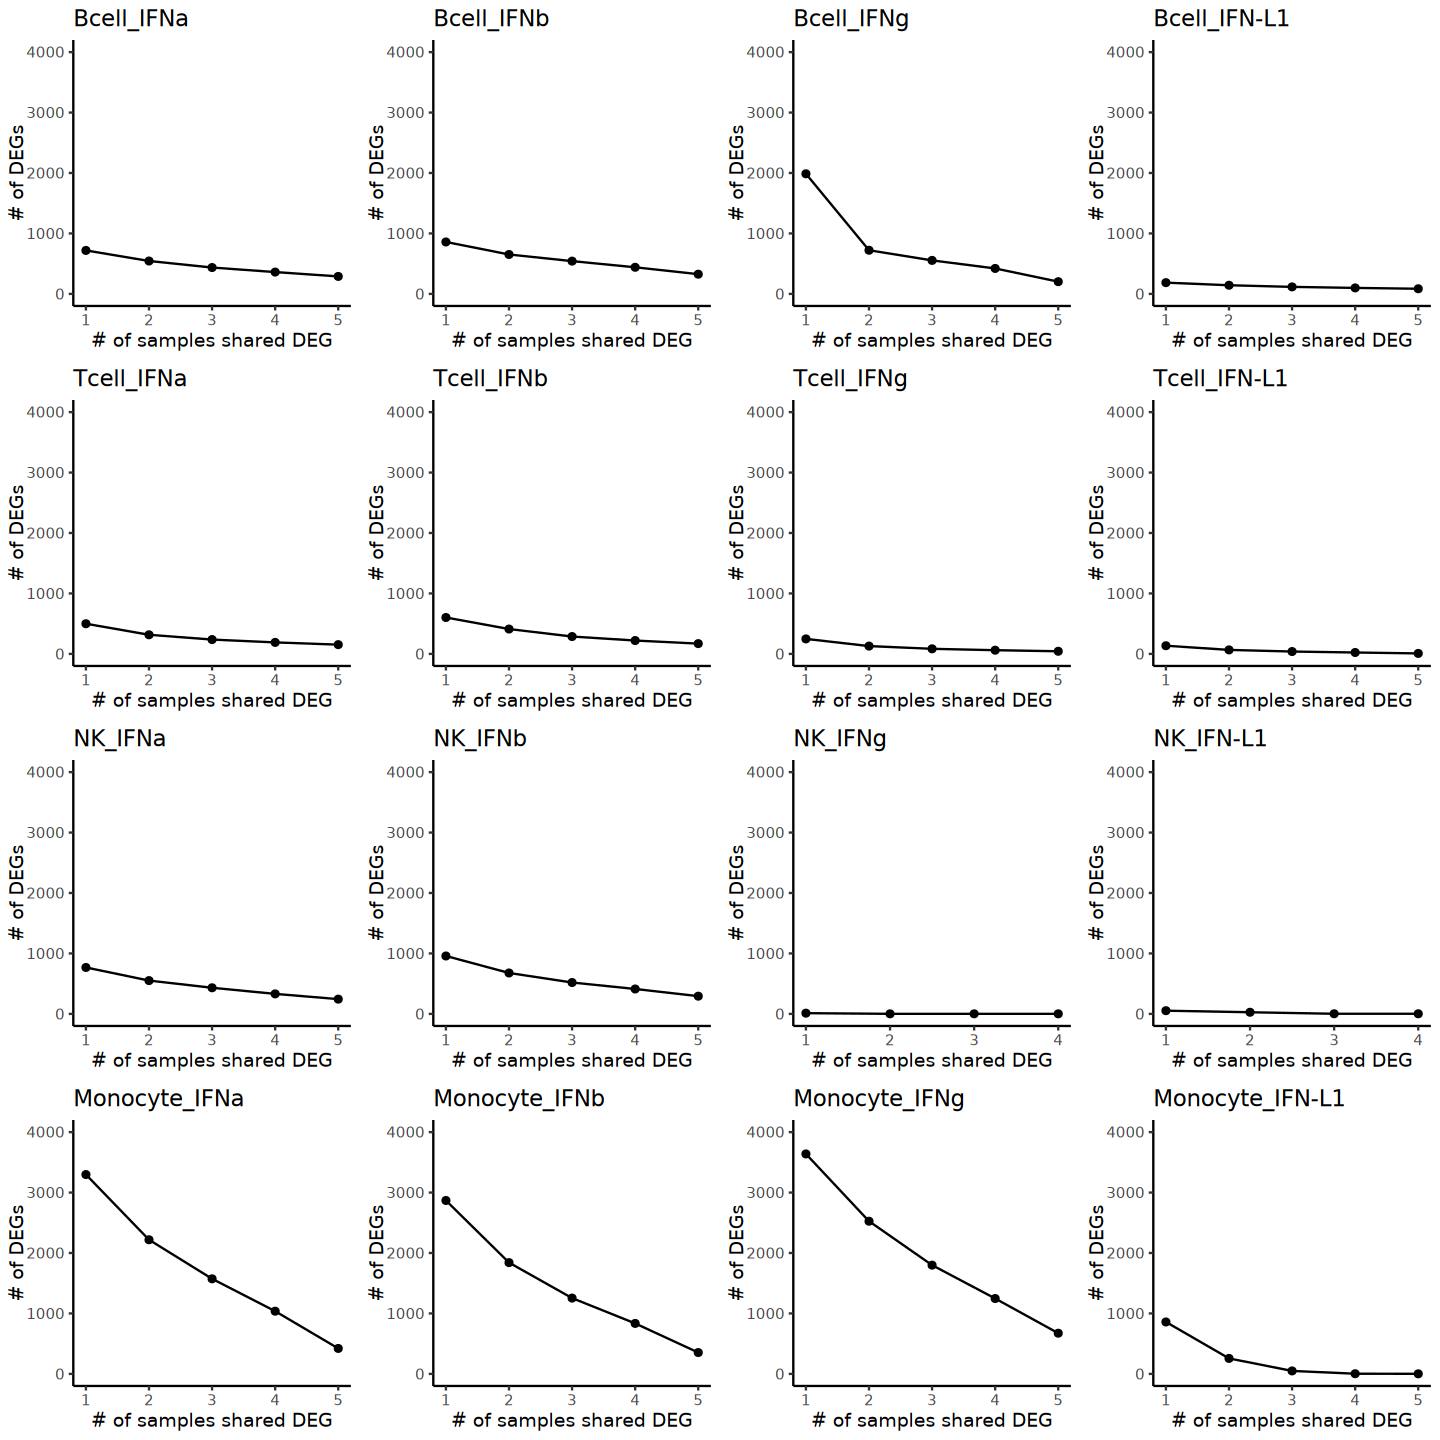

In [9]:
fig.size(12,12)
#pdf(file.path("/home/jupyter/Figures/", "Supp", "DEGs_Elbow_Plots.pdf"), height = 11, width = 11)
grid.arrange(grobs = ggs)
dev.off()

### 1D. Receptor nISGs Correlation Scatterplots

In [29]:
subtypes <- c("CD4 Naive", "CD4 Memory", "Treg", "CD8 Naive", "CD8 Memory", "MAIT", "gdT", 
              "B Naive", "B Memory", "Plasma", 
              "NK CD56hi", "NK CD56dim", 
              "Monocyte")

In [30]:
# read in object with all cells and receptor expression
#so <- readRDS(file.path(wd, "seurat_objects", "so_complete2.rds"))
so$Subtype <- so$Subtype %>% recode(
    "Naive" = "B Naive",
    "Memory" = "B Memory"
)

In [31]:
receptors <- c("IFNAR1",
               "IFNAR2",
               "IFNLR1",
               "IFNGR1",
               "IFNGR2",
               "IL10RB"
                )

In [32]:
Idents(so) <- "Description"

In [33]:
so$Description <- factor(so$Description, levels = c("none", stims))

In [34]:
so$Celltype_Description <- paste(so$Celltype, so$Description, sep = "_")

In [35]:
# get N DEGs per stim and cell type
l2_summary <- l2_degs %>% 
    group_by(stim, celltype) %>%
    summarise(nDEGs = n()) %>% 
    mutate(celltype = recode(celltype,
    "NK.CD56dim" = "NK CD56dim",
    "NK.CD56hi" = "NK CD56hi",
    "CD14 Monocyte" = "Monocyte"
))

`summarise()` has grouped output by 'stim'. You can override using the
`.groups` argument.


In [36]:
# get average receptor expression per cell type
receptors <- c("IFNAR1",
               "IFNGR1",
               "IFNLR1",
               "IFNAR2", 
               "IFNGR2",
               "IL10RB"
                )

avgexp <- AverageExpression(so, features = receptors, 
                 group.by = "Subtype", return.seurat = T)

avgexp_df <- avgexp@assays$RNA@layers$data %>% as.data.frame()

rownames(avgexp_df) <- rownames(avgexp@assays$RNA@features)
colnames(avgexp_df) <- rownames(avgexp@assays$RNA@cells)
avgexp_df$receptor <- rownames(avgexp_df)

avgexp_df <- avgexp_df %>% pivot_longer(!receptor, names_to = "celltype", values_to = "Expression") 



As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.
Centering and scaling data matrix



In [37]:
# associate IFNs with their receptor
avgexp_df$stim <- ifelse(avgexp_df$receptor %in% c("IFNAR1", "IFNAR2"), "IFNa", 
                     ifelse(avgexp_df$receptor %in% c("IFNGR1", "IFNGR2"), "IFNg", "IFN-L1")
                         )
avgexp_df$celltype_sort <- avgexp_df$celltype

In [38]:
# join receptor expression and nDEGs data frames
deg_exp_df <- dplyr::left_join(avgexp_df, l2_summary, by = c("stim", "celltype"))

deg_exp_df$celltype <- factor(deg_exp_df$celltype, levels = subtypes) 
deg_exp_df$receptor <- factor(deg_exp_df$receptor, levels = receptors)

In [39]:
deg_exp_df$nDEGs <- ifelse(is.na(deg_exp_df$nDEGs), 0, deg_exp_df$nDEGs)

In [40]:
subtype_cols <- c("#03045e", "#023e8a", "#0077b6", "#0096c7", "#00b4d8", "#48cae4", "#90e0ef",
                   "#1b4332", "#52b788", "#b7e4c7",
                    "#ff9f1c", "#ffbf69", 
                   "#78290f"
                  )

In [22]:
# for each receptor, generate correlation scatterplot of receptor expression vs nDEGs
ggs <- lapply(receptors, function(r){
    
    deg_exp_df_sub <- deg_exp_df %>% subset(receptor == r)
    
    cor <- cor.test(deg_exp_df_sub$Expression, deg_exp_df_sub$nDEGs, method = "spearman")

    print(r)
    print(cor)
    celltype_highlight <- NA
    if (r %like% "IFNG"){
        celltype_highlight <- c("Plasma", "B Naive", "B Memory", "Monocyte")
        }
    if (r %like% "IFNL"){
        celltype_highlight <- c("CD8 Memory", "Plasma")
        }
    
    deg_exp_df_sub$label <- ifelse(deg_exp_df_sub$celltype %in% celltype_highlight, as.character(deg_exp_df_sub$celltype), NA)
  
    ggplot(deg_exp_df_sub, aes(x=Expression, y=nDEGs)) + 
        geom_point(aes(color=celltype)) + 
        #ggrepel::geom_text_repel(label=deg_exp_df_sub$label, show.legend = FALSE, aes(color=celltype), max.overlaps = 100) + 
        labs(x = "Receptor Expression",
            y = "nISGs") + 
        theme_classic() + 
        scale_color_manual(values = subtype_cols) + 
        xlim(0, 2.5) + 
        ylim(0, 700) + 
        theme(legend.title = element_blank(), plot.title = element_text(hjust = 0.5)) + 
        ggtitle(glue("{r} (r={round(cor$estimate, 2)})")) + 
        theme(legend.position = "none")
        
    })

Warning message in cor.test.default(deg_exp_df_sub$Expression, deg_exp_df_sub$nDEGs, :
“Cannot compute exact p-value with ties”


[1] "IFNAR1"

	Spearman's rank correlation rho

data:  deg_exp_df_sub$Expression and deg_exp_df_sub$nDEGs
S = 424.08, p-value = 0.59
alternative hypothesis: true rho is not equal to 0
sample estimates:
       rho 
-0.1650621 



Warning message in cor.test.default(deg_exp_df_sub$Expression, deg_exp_df_sub$nDEGs, :
“Cannot compute exact p-value with ties”


[1] "IFNGR1"

	Spearman's rank correlation rho

data:  deg_exp_df_sub$Expression and deg_exp_df_sub$nDEGs
S = 108.83, p-value = 0.3358
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.3404271 



Warning message in cor.test.default(deg_exp_df_sub$Expression, deg_exp_df_sub$nDEGs, :
“Cannot compute exact p-value with ties”


...

[1] "IFNAR2"

	Spearman's rank correlation rho

data:  deg_exp_df_sub$Expression and deg_exp_df_sub$nDEGs
S = 476.15, p-value = 0.3057
alternative hypothesis: true rho is not equal to 0
sample estimates:
       rho 
-0.3081158 



Warning message in cor.test.default(deg_exp_df_sub$Expression, deg_exp_df_sub$nDEGs, :
“Cannot compute exact p-value with ties”


[1] "IFNGR2"

	Spearman's rank correlation rho

data:  deg_exp_df_sub$Expression and deg_exp_df_sub$nDEGs
S = 24.574, p-value = 0.001791
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.8510678 



Warning message in cor.test.default(deg_exp_df_sub$Expression, deg_exp_df_sub$nDEGs, :
“Cannot compute exact p-value with ties”


[1] "IL10RB"

	Spearman's rank correlation rho

data:  deg_exp_df_sub$Expression and deg_exp_df_sub$nDEGs
S = 376.76, p-value = 0.3148
alternative hypothesis: true rho is not equal to 0
sample estimates:
       rho 
-0.3173516 



null device 
          1

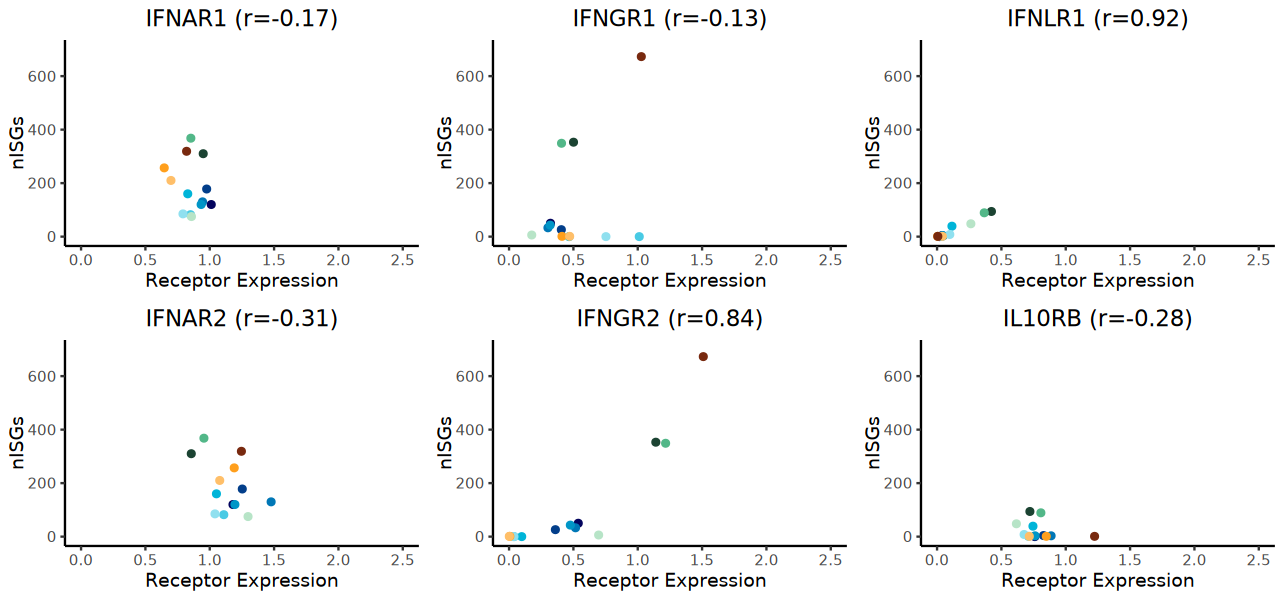

In [121]:
fig.size(5,10.7)
#pdf(file.path(fig_dir, "Supp", "Sup1", "IFN_Receptor_nDEGs_Scatterplots.pdf"), height = 5, width = 10)
grid.arrange(grobs = ggs , ncol = 3)
dev.off()

### 1E. Receptor Expression Stim Dotplot

In [25]:
receptors <- c('IFNAR1', 'IFNAR2',  'IFNGR1', 'IFNGR2', 'IFNLR1', 'IL10RB')

null device 
          1

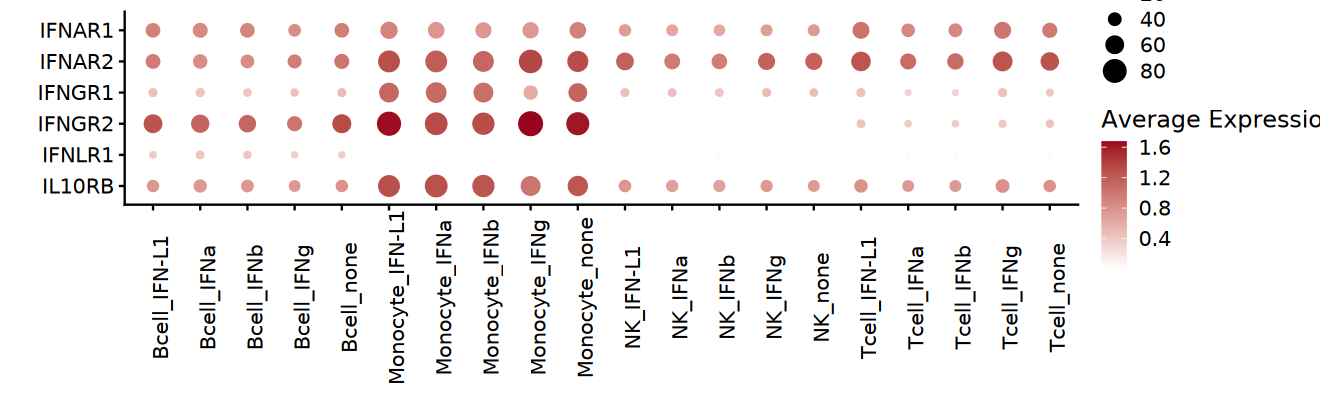

In [32]:
fig.size(3.5,11)
#pdf(file.path(wd, "Figures", "Supp", "Sup1", "IFN_Receptor_Expression_Subtype_Description_DotPlot.pdf"),
#   height = 3.5, width = 11)
DotPlot(so, 
        features = rev(receptors), 
        group.by = "Celltype_Description",
        scale = F,
        cols= c("white", "#9a031e")) + 
    theme(axis.text.x = element_text(angle = 90)) + 
    labs(x = "", y = "") + 
    coord_flip()
dev.off()

### 1F. Receptor Expression DEG Violin Plots

In [79]:
sub <- so %>% subset(Description %in% c("none", "IFNa", "IFNg"))

In [89]:
stim_cols <- c("#e9c46a", "#f4a261", "#e76f51", "#264653", "#2a9d8f")

sub$DescDonor <- paste0(sub$Description, "_", sub$DonorID)

sub$DescDonor <- factor(
  sub$DescDonor,
  levels = c(
    sort(unique(sub$DescDonor[grepl("^none_", sub$DescDonor)])),
    sort(unique(sub$DescDonor[grepl("^IFNa_", sub$DescDonor)])),
    sort(unique(sub$DescDonor[grepl("^IFNg_", sub$DescDonor)]))
  )
)

In [95]:
# g1: B Memory (none vs IFNa)
g1 <- VlnPlot(
  sub %>% subset(Subtype == "B Memory" & Description %in% c("none", "IFNa")),
  features = "IFNGR2", group.by = "DescDonor", pt.size = 0.0, raster = FALSE
) +
  ggtitle("IFNGR2: Memory B") + theme(legend.position = "none") + xlab("") +
  scale_fill_manual(values = c(rep("#e9c46a", 5), rep("#f4a261", 5)))
  
# g2: B Naive (none vs IFNg)
g2 <- VlnPlot(
  sub %>% subset(Subtype == "B Naive" & Description %in% c("none", "IFNg")),
  features = "IFNGR2", group.by = "DescDonor", pt.size = 0.0, raster = FALSE
) +
  ggtitle("IFNGR2: Naive B") + theme(legend.position = "none") + xlab("") +
  scale_fill_manual(values = c(rep("#e9c46a", 5), rep("#264653", 5)))

# g3: B Memory (none vs IFNg)
g3 <- VlnPlot(
  sub %>% subset(Subtype == "B Memory" & Description %in% c("none", "IFNg")),
  features = "IFNGR2", group.by = "DescDonor", pt.size = 0.0, raster = FALSE
) +
  ggtitle("IFNGR2: Memory B") + theme(legend.position = "none") + xlab("") +
  scale_fill_manual(values = c(rep("#e9c46a", 5), rep("#264653", 5)))

# g4: Monocyte (none vs IFNg)
g4 <- VlnPlot(
  sub %>% subset(Subtype == "Monocyte" & Description %in% c("none", "IFNg")),
  features = "IFNGR1", group.by = "DescDonor", pt.size = 0.0, raster = FALSE
) +
  ggtitle("IFNGR1: CD14 Mono") + theme(legend.position = "none") + xlab("") +
  scale_fill_manual(values = c(rep("#e9c46a", 5), rep("#264653", 5)))

null device 
          1

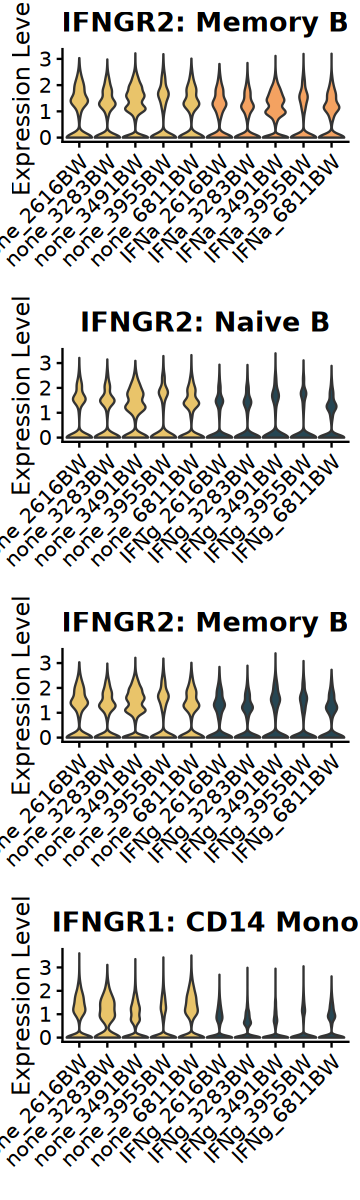

In [97]:
fig.size(10,3)
#pdf(file.path(fig_dir, "Supp", "Sup1", "IFN_Receptor_Expression_DEGs_Violin_Plot.pdf"), height = 5, width = 5)
grid.arrange(grobs = list(g1, g2, g3, g4), ncol = 1)
dev.off()